# 2. Data Preparation

**(CRISP-DM Phase 3:** Transform raw data into a clean, merged **Analytical Base Table (ABT)** ready for modelling.)

## Table of Contents

- [1.1 Overview](#11-overview)
- [1.2 Setup](#12-setup)
- [2.1 Load Raw Datasets](#21-load-raw-datasets)
- [2.2 Remove irrelevant features](#22-remove-irrelevant-features)
  - [2.2.1 Clean `bdoss`](#221-clean-bdoss)
  - [2.2.2 Clean `crc`](#222-clean-crc)
  - [2.2.3 Clean `credscore`](#223-clean-credscore)
  - [2.2.4 Clean `Fama`](#224-clean-fama)
- [2.3 Handling Missing Values](#23-handling-missing-values)
  - [2.3.1 Missing Values `Bdoss`](#231-missing-values-bdoss)
  - [2.3.2 Missing Values `CRC`](#232-missing-values-crc)
  - [2.3.3 Missing Values `CredScore`](#233-missing-values-credscore)
  - [2.3.4 Missing Values `FAMA`](#234-missing-values-fama)
- [2.4 Handling Duplicates](#24-handling-duplicates)
  - [2.4.1 Duplicates `BDOSS`](#241-duplicates-bdoss)
  - [2.4.2 Duplicates `CRC`](#242-duplicates-crc)
  - [2.4.3 Duplicates `CredScore`](#243-duplicates-credscore)
  - [2.4.4 Duplicates `FAMA`](#244-duplicates-fama)
- [2.5 Outliers Report](#25-outliers-report)
  - [2.5.1 Outliers Summary `BDOSS`](#251-outliers-summary-bdoss)
  - [2.5.2 Outliers Summary `CRC`](#252-outliers-summary-crc)
  - [2.5.3 Outliers Summary `CredScore`](#253-outliers-summary-credscore)
  - [2.5.4 Outliers Summary `FAMA`](#254-outliers-summary-fama)
- [2.6 Aggregate Datasets](#26-aggregate-datasets)
  - [2.6.1 BDOSS Aggregation](#261-bdoss-aggregation)
  - [2.6.2 CRC Aggregation](#262-crc-aggregation)
  - [2.6.3 CREDSCORE Deduplication](#263-credscore-deduplication)
  - [2.6.4 FAMA Latest Observation](#264-fama-latest-observation)
- [2.7 Merge Datasets → Analytical Base Table (ABT)](#27-merge-datasets--analytical-base-table-abt)
- [2.8 ABT Quality Check](#28-abt-quality-check)
  - [2.8.1 Shape & Duplicates](#281-shape--duplicates)
  - [2.8.2 Key Uniqueness](#282-key-uniqueness)
  - [2.8.3 Join Coverage](#283-join-coverage)
  - [2.8.4 Missing Values Summary](#284-missing-values-summary)
  - [2.8.5 Date Logic Coherence](#285-date-logic-coherence)
  - [2.8.6 Numeric Range Sanity](#286-numeric-range-sanity)
  - [2.8.7 Near-Constant Columns](#287-near-constant-columns)
  - [2.8.8 Target Distribution](#288-target-distribution)
  - [2.8.9 Data Types & Feature Inventory](#289-data-types--feature-inventory)
- [2.9 Save ABT](#211-save-abt)

## 1.1 Overview

This notebook covers the **Data Preparation** phase of the project, which transforms the raw datasets into a clean, unified **Analytical Base Table (ABT)** ready for feature engineering and modelling.

The preparation is structured into the following steps:

- **2.1 Load Raw Datasets** — load all four raw data sources into memory.
- **2.2 Remove Irrelevant Features** — drop columns identified during Data Understanding as having no analytical value, and convert date columns to the correct `datetime` type.
- **2.3 Handling Missing Values** — detect and impute missing values per data type: median for numerics, forward fill for datetimes, and `"Unknown"` for categoricals.
- **2.4 Handling Duplicates** — remove exact duplicate rows and resolve key-level duplicates by keeping the most complete record.
- **2.5 Outliers Report** — flag potential outliers in numeric columns using IQR and Z-score methods. No data is modified at this stage — results are reported for review.

TODO: Check if this is still right? @e

- **2.6 Aggregate Datasets** — reduce each dataset to one row per customer (CONTRIB): BDOSS via two-stage groupby aggregation + target engineering, CRC via min/max/median, CREDSCORE by keeping the highest risk tier, and FAMA by keeping the most recent observation.
- **2.7 Merge Datasets → ABT** — left-join all four customer-level datasets on CONTRIB into a single Analytical Base Table.
- **2.8 ABT Quality Check** — validate the merged ABT: shape, key uniqueness, join coverage, missing values, date coherence, numeric ranges, near-constant columns, and target distribution.
- **2.9 Save ABT** — persist the final ABT as a Parquet file for use in subsequent notebooks.

To ensure consistency across datasets, steps 2.2–2.5 rely on reusable functions defined once and applied to each dataset individually before aggregation.

---
## 1.2 Setup

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.data_preparation as dp
import src.code.data_functions as dfun
import src.code.io_utils as io

importlib.reload(dp)
importlib.reload(dfun)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# Path constants
BDOSS_PATH    = io.data_path("bdoss.csv")
CRC_PATH      = io.data_path("crc.csv")
CREDSCORE_PATH = io.data_path("credscore.csv")
FAMA_PATH     = io.data_path("fama.csv")
ABT_OUT_PATH  = "../data/prepared/abt.parquet"

print("Setup complete.")

Setup complete.


---
## 2.1 Load Raw Datasets

> All four datasets are loaded from the `../data/converted/` folder (CSV format).  
> Loading uses `io_utils.load()`, which prints shape information automatically.

In [2]:
# Main loan-level dataset - large, takes a few seconds to load
bdoss_raw = io.load(BDOSS_PATH)
bdoss_raw.head(3)

[LOAD] c:\Users\Asus\OneDrive\Documentos\NOVA IMS\2º semestre\Business Cases\1 - BNP Paribas\Business_Case_BNP\data\converted\bdoss.csv | shape: (2658187, 35)


,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.000,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,69.000,69.000,20000.000,20000.000,347.447,NaN,13208.455,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,120.000,P,1113.258,80.000,1988.000,P,2845,1.000,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.000,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.000,34.000,34.000,2500.000,2500.000,56.018,NaN,0.000,0.000,NaN,1.000,1.000,000000000000210210000110,0.000,120.000,N,838.186,91.000,1990.000,P,2855,0.000,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.000,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,52.000,52.000,5000.000,5000.000,100.074,NaN,2665.191,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,118.000,P,1314.144,80.000,2013.000,P,2635,2.000,W


In [3]:
# Credit bureau monthly data
crc_raw = io.load(CRC_PATH)
crc_raw.head(3)

[LOAD] c:\Users\Asus\OneDrive\Documentos\NOVA IMS\2º semestre\Business Cases\1 - BNP Paribas\Business_Case_BNP\data\converted\crc.csv | shape: (3034921, 22)


,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.000,4.000,0.000,0.000,0.000,1.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6842.100,963.550,0.000,0.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.180,4.000,5.000,0.000,0.000,0.000,1.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,28532.060,7115.460,0.000,0.000
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.000,5.000,1.000,1.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2957.280,2150.900,2408.560,85549.490


In [4]:
# Credit score per customer
credscore_raw = io.load(CREDSCORE_PATH)
credscore_raw.head(3)

[LOAD] c:\Users\Asus\OneDrive\Documentos\NOVA IMS\2º semestre\Business Cases\1 - BNP Paribas\Business_Case_BNP\data\converted\credscore.csv | shape: (63704, 5)


,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.000,2025-02-05,H,2.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.000,2025-04-09,D,1.000
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.000,2023-08-08,F,3.000


In [5]:
# Aggregated customer-level features + socio-demographics
fama_raw = io.load(FAMA_PATH)
fama_raw.head(3)

[LOAD] c:\Users\Asus\OneDrive\Documentos\NOVA IMS\2º semestre\Business Cases\1 - BNP Paribas\Business_Case_BNP\data\converted\fama.csv | shape: (141115, 23)


,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.000,6.000,9.000,1.000,0.000,88784.040,0.000,88784.040,0.000,4443.000,-808.000,1280.533,0.000,1153.000,1153.000,120.000,0.425,15.000,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.000,4.000,2.000,1.000,2.000,9584.910,7628.410,9584.910,0.000,3120.000,-2077.000,466.333,14.000,1564.667,1582.000,72.000,0.139,6.000,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.000,5.000,3.000,1.000,0.000,22000.860,0.000,22000.860,0.000,4936.000,-2089.000,907.625,0.000,1765.000,1765.000,36.000,0.278,8.000,C,L,65


---
## 2.2 Remove irrelevant features
During the **Data Understanding** phase, we identified across the datasets a set of columns that are not relevant for the analysis and should be dropped, as well as columns stored as strings that represent dates and need to be converted to the correct `datetime` type.
The decisions taken were:

* **Remove columns that were identified as irrelevant** — duplicated identifiers, free-text fields with no analytical value, or internal system columns that carry no signal for the problem at hand.
* **Convert to datetime column**s that represent dates or timestamps but were loaded as strings, so that time-based operations and feature engineering can be applied correctly downstream.

To keep this step consistent and reusable across all datasets, we defined a single function **initial_preparation()** that handles both operations. Columns passed that do not exist in a given dataset are silently ignored, since not all datasets share the same structure.

### 2.2.1 Clean `bdoss`

In [6]:
bdoss_clean = dp.clean_bdoss(bdoss_raw)

[clean_bdoss] Dropping 1 fully-null cols: ['MENSALIDADE_CORR']
[clean_bdoss] shape: (2658187, 35) | RISK distribution:
{0: 2414813, -9223372036854775808: 122135, 10000000: 8712, 100000000: 5957, 1000000000: 5424, 10000000000: 5016, 100000000000: 4644, 1000000000000: 4377, 10000000000000: 3899, 1000000000000000: 3645, 100000000000000: 3611, 10000000000000000: 3356, 100000000000000000: 3145, 1000000000000000000: 3075, 110000000: 1725, 20000000: 1413, 120000000: 1026, 1100000000: 747, 200000000: 730, 2000000000: 718, 20000000000: 598, 210000000: 596, 11000000000: 590, 2000000000000: 584, 1110000000: 581, 200000000000: 558, 200000000000000: 465, 110000000000: 462, 1220000000: 453, 1100000000000: 446, 11000000000000: 429, 20000000000000000: 415, 1200000000: 413, 20000000000000: 411, 1010000000: 402, 1100000000000000: 401, 2000000000000000000: 387, 10010000000: 358, 110000000000000: 343, 11000000000000000: 343, 2000000000000000: 338, 200000000000000000: 334, 11110000000: 322, 12000000000: 31

### 2.2.2 Clean `crc`

In [7]:
crc_clean = dp.clean_crc(crc_raw)

[clean_crc] shape: (3034921, 24)


### 2.2.3 Clean `credscore`

In [8]:
credscore_clean = dp.clean_credscore(credscore_raw)

[clean_credscore] shape: (63704, 4)


### 2.2.4 Clean `Fama`

In [9]:
fama_clean = dp.clean_fama(fama_raw)

[clean_fama] shape: (141115, 23)


---
## 2.3 Handling Missing Values

TODO: is this still right? @e

After the initial preparation, we assessed the presence of missing values across all datasets. The goal of this step is to ensure no nulls are carried forward into feature engineering or modelling, as these can cause errors or silently distort results.

The strategy applied follows the data types identified in each dataset:

- **Numeric columns** — imputed with the **median**, which is more robust to outliers than the mean.
- **Datetime columns** — imputed with **forward fill** (`ffill`), propagating the last known date forward. This is appropriate when records have a natural time order and a missing date is likely close to the previous one.
- **Categorical columns** — filled with `"Unknown"`, making the missingness explicit and preserving the row rather than discarding it.
- **Rows** — any row missing more than 50% of its values is dropped before imputation, as imputing heavily incomplete records would introduce more noise than signal.

As with the previous step, a reusable function `handle_missing_values()` was defined and applied consistently across all datasets.

### 2.3.1 Missing Values `Bdoss`


In [10]:
bdoss_clean = dp.handle_missing_values(df= bdoss_clean,dataset_name= "BDOSS")

[BDOSS]
  Missing before     : 353945
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (2) [fixed] : ['RANGCLI', 'NBENF']
  Datetime imputed (1) [ffill]  : ['DCSP']
  Categ.  imputed  (2) [Unknown]  : ['NATIO', 'MODCONTACTO']
  Missing after      : 0



### 2.3.2 Missing Values `CRC`

In [11]:
crc_clean = dp.handle_missing_values(df= crc_clean,dataset_name= "CRC")

[CRC]
  Missing before     : 2005203
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (1) [fixed] : ['MT_MENSAL']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.3 Missing Values `CredScore`

In [12]:
credscore_clean= dp.handle_missing_values(df= credscore_clean,dataset_name= "CredScore")


[CredScore]
  Missing before     : 21921
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (1) [fixed] : ['kp_sqe_enc']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.4 Missing Values `FAMA`

In [13]:
fama_clean= dp.handle_missing_values(df= fama_clean,dataset_name= "Fama")

[Fama]
  Missing before     : 0
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (0) [fixed] : —
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



---
## 2.4 Handling Duplicates

With missing values addressed, we then checked for duplicate records across all datasets. Duplicates can silently distort model training by overrepresenting certain records, so it is important to remove them before moving forward.

We distinguish between two types of duplicates:

- **Exact duplicates** — rows that are completely identical across all columns. These are dropped unconditionally, as they carry no additional information.
- **Key duplicates** — rows that share the same primary key (e.g. `CONTRIB`, `OBS_DATE`) but differ in other columns, which can happen due to data ingestion issues or system errors. When found, we keep the row with the fewest missing values, as it is the most complete record.

Note that not all datasets have a single unique key per row by design — for example, a dataset with monthly entries per user will naturally repeat `CONTRIB` across rows. In those cases, `key_cols` is not passed and only exact duplicates are removed.

A reusable function `handle_duplicates()` was defined and applied consistently across all datasets.

### 2.4.1 Duplicates `BDOSS`

In [14]:
bdoss_clean = dp.handle_duplicates(
    df=bdoss_clean, dataset_name="BDOSS", key_cols=["CONTRIB", "DOSSIER", "OBS_DATE"]
)

[BDOSS]
  Rows before        : 2658187
  Exact duplicates   : 0 dropped
  Key duplicates     : 0 dropped  (key: ['CONTRIB', 'DOSSIER', 'OBS_DATE'])
  Rows after         : 2658187  (total dropped: 0)



### 2.4.2 Duplicates `CRC`

In [15]:
crc_clean = dp.handle_duplicates(
    df=crc_clean, dataset_name="CRC", key_cols=["CONTRIB", "OBS_DATE"]
)

[CRC]
  Rows before        : 3034921
  Exact duplicates   : 0 dropped
  Key duplicates     : 0 dropped  (key: ['CONTRIB', 'OBS_DATE'])
  Rows after         : 3034921  (total dropped: 0)



### 2.4.3 Duplicates `CredScore`


In [16]:
credscore_clean = dp.handle_duplicates(
    df=credscore_clean, dataset_name="CredScore", key_cols=["CONTRIB", "sys_data_procura"]
)

[CredScore]
  Rows before        : 63704
  Exact duplicates   : 835 dropped
  Key duplicates     : 546 dropped  (key: ['CONTRIB', 'sys_data_procura'])
  Rows after         : 62323  (total dropped: 1381)



### 2.4.4 Duplicates `FAMA`


In [17]:
fama_clean = dp.handle_duplicates(
    df=fama_clean, dataset_name="FAMA", key_cols=["CONTRIB", "Date_Obs"]
)

[FAMA]
  Rows before        : 141115
  Exact duplicates   : 0 dropped
  Key duplicates     : 0 dropped  (key: ['CONTRIB', 'Date_Obs'])
  Rows after         : 141115  (total dropped: 0)



In [18]:
# TODO This can be deleted now, right? @e

# os.makedirs("../data/prepared", exist_ok=True)

# print("Saving cleaned datasets as Parquet...")

# io.save(bdoss_clean, "../data/prepared/bdoss_clean.parquet")
# print("- BDOSS saved.")

# io.save(crc_clean, "../data/prepared/crc_clean.parquet")
# print("- CRC saved.")

# io.save(credscore_clean, "../data/prepared/credscore_clean.parquet")
# print("- CREDSCORE saved.")

# io.save(fama_clean, "../data/prepared/fama_clean.parquet")
# print("- FAMA saved.")

---
## 2.5 Outliers Report

Before merging the datasets, we ran outlier detection on all numeric columns. At this stage the goal is purely diagnostic — no data is modified. The decision on how to handle each outlier (remove, cap, or leave) will be made in context, after reviewing the results and considering the modelling approach to be used downstream.

Two complementary methods were applied:

- **IQR (Interquartile Range)** — flags values that fall below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. More robust to skewed distributions and effective at catching extreme values relative to the bulk of the data.
- **Z-score** — flags values more than 3 standard deviations from the mean. Works best on roughly normal distributions and is more sensitive to moderate but consistent deviations.

Using both methods together gives a fuller picture: a value flagged by both is almost certainly a true outlier, while one flagged by only one method may warrant a closer look.

The function `detect_outliers()` reports the count and percentage of flagged rows per column but does not return a modified DataFrame.

### 2.5.1 Outliers Summary `BDOSS`

In [19]:
dp.detect_outliers(df=bdoss_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  BICONTRATO                             0                 0     0.0%
  DURDEG                             14290                 0     0.5%
  RANGPRO                             6515              5353     0.2%
  RANGCLI                            39691              7447     1.5%
  MTFINO                            146804             52980     5.5%
  MTFIN                             146819             52980     5.5%
  MENSALIDADE                       160645             53334     6.0%
  CRD                               171314             56624     6.4%
  SREC                              167187              6590     6.3%
  RN                                387888            130518    14.6%
  RD                                387270            104238    14.6%
  RISK                              243374            122135  

### 2.5.2 Outliers Summary `CRC`

In [20]:
dp.detect_outliers(df=crc_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  MT_MENSAL                         339436              1242    11.2%
  COUNT_CL                          282883             41934     9.3%
  COUNT_CP                          117466             34432     3.9%
  COUNT_AUTO                         52941             52941     1.7%
  COUNT_HT                           44455             44455     1.5%
  COUNT_CONEXO                      193001            193001     6.4%
  COUNT_OTHER                        90843             29180     3.0%
  COUNT_TOTAL                        93557             40653     3.1%
  MONTVENC_CL                       114199              8806     3.8%
  MONTVENC_CP                       135750             18423     4.5%
  MONTVENC_AUTO                      37100              4492     1.2%
  MONTVENC_HT                        18812              1168  

### 2.5.3 Outliers Summary `CredScore`

In [21]:
dp.detect_outliers(df=credscore_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  ks_score_tier                        767               247     1.2%
  kp_sqe_enc                             0                 0     0.0%
  ------------------------- -------------- ----------------- --------
  TOTAL                                767               247



### 2.5.4 Outliers Summary `FAMA`

In [22]:
dp.detect_outliers(df=fama_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  ALLBD_N_Dossiers__N                 5393              2073     3.8%
  ALLBD_N_CL__N                       5897              2112     4.2%
  ALLBD_N_CP__N                       3199              2119     2.3%
  ALLBD_A_CL__N                       1347              1347     1.0%
  ALLBD_A_CP__N                       3626               554     2.6%
  ALLBD_MTFINO_CL__N                  9220              2839     6.5%
  ALLBD_MTFINO_CP__N                 14926              2380    10.6%
  ALLBD_MTFIN_CL__N                   9156              2647     6.5%
  ALLBD_MTFIN_CP__N                  27906              3949    19.8%
  ALLBD_IDADE_MSA__N                     1                 1     0.0%
  ALLBD_IDADE_MIN__N                  7537              2968     5.3%
  ALLBD_IDADE_MEAN__N                 1613               885  

---
## 2.6 Aggregate Datasets

Each dataset is reduced to **one row per customer** (CONTRIB) before the merge.

- **BDOSS** → contract-level → customer-level aggregation + target variables
- **CRC** → min / max / median per customer across all monthly observations
- **CREDSCORE** → one row per customer (keep highest `ks_score_tier`)
- **FAMA** → most recent observation per customer

### 2.6.1 BDOSS Aggregation

In [23]:
#Step 1: Sort + derive POS flags per contract

# Sort so last aggregation = most recent observation per contract
bdoss_clean = bdoss_clean.sort_values(["CONTRIB", "DOSSIER", "OBS_DATE"])

# Vectorized pivot: for each contract, capture first OBS_DATE per POS status (SOL/SAN/RBT)
pos_min = (
    bdoss_clean[bdoss_clean["POS"].isin(["SOL", "SAN", "RBT"])]
    .groupby(["CONTRIB", "DOSSIER", "POS"])["OBS_DATE"]
    .min()
    .reset_index()
    .pivot(index=["CONTRIB", "DOSSIER"], columns="POS", values="OBS_DATE")
    .reset_index()
)
pos_min.columns.name = None
pos_min = pos_min.rename(columns={"SOL": "OBS_DATE_SOL", "SAN": "OBS_DATE_SAN", "RBT": "OBS_DATE_RBT"})

for pos_val in ["SOL", "SAN", "RBT"]:
    pos_min[f"HAS_{pos_val}"] = pos_min[f"OBS_DATE_{pos_val}"].notna().astype(int)

pos_flags = pos_min[["CONTRIB", "DOSSIER",
                      "HAS_SOL", "HAS_SAN", "HAS_RBT",
                      "OBS_DATE_SOL", "OBS_DATE_SAN", "OBS_DATE_RBT"]]
print(f"pos_flags shape: {pos_flags.shape}")

pos_flags shape: (77690, 8)


In [24]:
#Step 2: Contract-level aggregation (one row per CONTRIB × DOSSIER)

drop_cols = ["OBS_DATE", "POS", "DCSP", "PTT"]
bdoss_agg_input = bdoss_clean.drop(columns=drop_cols)

agg_dict_contract = {
    "DPOS":        "last",
    "DCREAT":      "last",
    "DATFIN":      "last",
    "D1FIN":       "last",
    "DURDEG":      "max",
    "RANGPRO":     "max",
    "RANGCLI":     "max",
    "MTFINO":      "max",
    "MTFIN":       "max",
    "MENSALIDADE": "median",
    "CRD":         "last",
    "SREC":        "last",
    "RN":          "max",
    "RD":          "max",
    "RISK":        "last",
    "RISKA":       "last",
    "RESSO":       "last",
    "CSP":         "last",
    "NBENF":       "last",
}

bdoss_aggregated = (
    bdoss_agg_input
    .groupby(["CONTRIB", "DOSSIER"], sort=False)
    .agg(agg_dict_contract)
    .reset_index()
)

# Attach POS flags and event dates
bdoss_aggregated = bdoss_aggregated.merge(pos_flags, on=["CONTRIB", "DOSSIER"], how="left")
for col in ["HAS_SOL", "HAS_SAN", "HAS_RBT"]:
    bdoss_aggregated[col] = bdoss_aggregated[col].fillna(0).astype(int)

print(f"bdoss_clean rows : {bdoss_clean.shape[0]:,}  →  bdoss_aggregated rows: {bdoss_aggregated.shape[0]:,}")

bdoss_clean rows : 2,658,187  →  bdoss_aggregated rows: 185,600


In [25]:
#Step 3: Customer-level aggregation (one row per CONTRIB)

# Sort so "last" picks the most recent contract per customer
bdoss_aggregated = bdoss_aggregated.sort_values(["CONTRIB", "DCREAT"])

agg_dict_customer = {
    "DOSSIER":       "count",
    "DCREAT":        ["min", "max"],
    "DPOS":          "max",
    "DATFIN":        "max",
    "D1FIN":         "min",
    "DURDEG":        ["min", "max", "median"],
    "RANGPRO":       ["min", "max", "median"],
    "RANGCLI":       ["min", "max", "median"],
    "MTFIN":         "sum",
    "MTFINO":        "sum",
    "MENSALIDADE":   "sum",
    "CRD":           "sum",
    "SREC":          "sum",
    "RN":            "sum",
    "RD":            "sum",
    "RISK":          "last",
    "RISKA":         "max",
    "RESSO":         ["min", "max", "median"],
    "CSP":           "last",
    "NBENF":         "last",
    "HAS_SOL":       ["max", "sum"],
    "HAS_SAN":       ["max", "sum"],
    "HAS_RBT":       ["max", "sum"],
    "OBS_DATE_SOL":  "max",
    "OBS_DATE_SAN":  "max",
    "OBS_DATE_RBT":  "max",
}

bdoss_customer = (
    bdoss_aggregated
    .groupby("CONTRIB", sort=False)
    .agg(agg_dict_customer)
    .reset_index()
)

col_rename = {
    ("CONTRIB",      ""):         "CONTRIB",
    ("DOSSIER",      "count"):    "N_CONTRACTS",
    ("DCREAT",       "min"):      "FIRST_DCREAT",
    ("DCREAT",       "max"):      "LAST_DCREAT",
    ("DPOS",         "max"):      "LAST_DPOS",
    ("DATFIN",       "max"):      "LAST_DATFIN",
    ("D1FIN",        "min"):      "FIRST_D1FIN",
    ("DURDEG",       "min"):      "MIN_DURDEG",
    ("DURDEG",       "max"):      "MAX_DURDEG",
    ("DURDEG",       "median"):   "MEDIAN_DURDEG",
    ("RANGPRO",      "min"):      "MIN_RANGPRO",
    ("RANGPRO",      "max"):      "MAX_RANGPRO",
    ("RANGPRO",      "median"):   "MEDIAN_RANGPRO",
    ("RANGCLI",      "min"):      "MIN_RANGCLI",
    ("RANGCLI",      "max"):      "MAX_RANGCLI",
    ("RANGCLI",      "median"):   "MEDIAN_RANGCLI",
    ("MTFIN",        "sum"):      "TOTAL_MTFIN",
    ("MTFINO",       "sum"):      "TOTAL_MTFINO",
    ("MENSALIDADE",  "sum"):      "TOTAL_MENSALIDADE",
    ("CRD",          "sum"):      "TOTAL_CRD",
    ("SREC",         "sum"):      "TOTAL_SREC",
    ("RN",           "sum"):      "TOTAL_RN",
    ("RD",           "sum"):      "TOTAL_RD",
    ("RISK",         "last"):     "LAST_RISK",
    ("RISKA",        "max"):      "MAX_RISKA",
    ("RESSO",        "min"):      "MIN_RESSO",
    ("RESSO",        "max"):      "MAX_RESSO",
    ("RESSO",        "median"):   "MEDIAN_RESSO",
    ("CSP",          "last"):     "CSP",
    ("NBENF",        "last"):     "NBENF",
    ("HAS_SOL",      "max"):      "EVER_SOL",
    ("HAS_SOL",      "sum"):      "N_SOL",
    ("HAS_SAN",      "max"):      "EVER_SAN",
    ("HAS_SAN",      "sum"):      "N_SAN",
    ("HAS_RBT",      "max"):      "EVER_RBT",
    ("HAS_RBT",      "sum"):      "N_RBT",
    ("OBS_DATE_SOL", "max"):      "LAST_OBS_DATE_SOL",
    ("OBS_DATE_SAN", "max"):      "LAST_OBS_DATE_SAN",
    ("OBS_DATE_RBT", "max"):      "LAST_OBS_DATE_RBT",
}
bdoss_customer.columns = [col_rename.get(col, col[0] if isinstance(col, tuple) else col)
                          for col in bdoss_customer.columns]

print(f"bdoss_aggregated rows: {bdoss_aggregated.shape[0]:,}  →  bdoss_customer rows: {bdoss_customer.shape[0]:,}")

bdoss_aggregated rows: 185,600  →  bdoss_customer rows: 148,729


**Step 4: Target Variable Engineering**

Objective 1 — Early Settlement (`IS_EARLY_SETTLER`)
A customer is an early settler if at least one of their contracts was ever in `SAN` or `RBT` status.

Objective 2 — Churn (`IS_CHURN`)
A customer churns if they paid off a contract (`SOL`, `SAN`, or `RBT`) **and** did not open a new contract within 30 days of that payoff date.

In [26]:
# Objective 1: IS_EARLY_SETTLER
bdoss_customer["IS_EARLY_SETTLER"] = (
    (bdoss_customer["EVER_SAN"] == 1) | (bdoss_customer["EVER_RBT"] == 1)
).astype(int)

# Objective 2:
last_end      = bdoss_customer[["LAST_OBS_DATE_SOL", "LAST_OBS_DATE_SAN", "LAST_OBS_DATE_RBT"]].max(axis=1)
had_end_event = bdoss_customer[["EVER_SOL", "EVER_SAN", "EVER_RBT"]].max(axis=1) == 1
gap_days      = (bdoss_customer["LAST_DCREAT"] - last_end).dt.days

bdoss_customer["IS_CHURN"] = (
    had_end_event & ((bdoss_customer["LAST_DCREAT"] <= last_end) | (gap_days > 30))
).astype(int)

print("IS_EARLY_SETTLER:", bdoss_customer["IS_EARLY_SETTLER"].value_counts().to_dict())
print("IS_CHURN        :", bdoss_customer["IS_CHURN"].value_counts().to_dict())

IS_EARLY_SETTLER: {0: 107354, 1: 41375}
IS_CHURN        : {0: 82407, 1: 66322}


### 2.6.2 CRC Aggregation

In [27]:
# Aggregate to customer level (min / max / median per column)

crc_cols = [
    "MT_MENSAL",
    "COUNT_CL", "COUNT_AUTO", "COUNT_TOTAL",
    "MONTVENC_CL", "MONTVENC_CP", "MONTVENC_AUTO", "MONTVENC_HT",
    "DIVIDAS_CL", "DIVIDAS_CP", "DIVIDAS_AUTO", "DIVIDAS_HT",
]
crc_agg_dict = {col: ["min", "max", "median"] for col in crc_cols}
crc_customer = (
    crc_clean.groupby("CONTRIB", sort=False).agg(crc_agg_dict).reset_index()
)
# Flatten MultiIndex: ("MT_MENSAL", "min") → "MT_MENSAL_MIN"
crc_customer.columns = [
    f"{col[0]}_{col[1].upper()}" if col[1] else col[0]
    for col in crc_customer.columns
]
print(f"crc_clean rows: {crc_clean.shape[0]:,}  →  crc_customer rows: {crc_customer.shape[0]:,}  ({crc_customer.shape[1]} cols)")

crc_clean rows: 3,034,921  →  crc_customer rows: 141,663  (37 cols)


### 2.6.3 CREDSCORE Deduplication

In [28]:
# Keep highest ks_score_tier per customer
# Prefer false positives over false negatives for credit risk scoring

credscore_best = (
    credscore_clean
    .sort_values("ks_score_tier", ascending=False)
    .drop_duplicates(subset="CONTRIB", keep="first")
    [["CONTRIB", "sys_data_procura", "kp_sqe_enc", "ks_score_tier"]]
)
print(f"credscore_clean rows: {credscore_clean.shape[0]:,}  →  credscore_best rows: {credscore_best.shape[0]:,}")

credscore_clean rows: 62,323  →  credscore_best rows: 62,173


### 2.6.4 FAMA Latest Observation

In [29]:
# Most recent observation per customer

fama_cols = ["CONTRIB", "ALLBD_N_Dossiers__N", "ALLBD_A_CL__N", "ALLBD_A_CP__N",
             "ALLBD_IDADE_MEAN__N", "ALLBD_N_events__N", "sdem_SITFAM", "sdem_HABITAT", "sdem_age"]
fama_latest = (
    fama_clean
    .sort_values("Date_Obs")
    .groupby("CONTRIB")
    .tail(1)
    [fama_cols]
)
print(f"fama_clean rows: {fama_clean.shape[0]:,}  →  fama_latest rows: {fama_latest.shape[0]:,}")

fama_clean rows: 141,115  →  fama_latest rows: 141,115


---
## 2.7 Merge Datasets → Analytical Base Table (ABT)

All four datasets are now at customer level (one row per CONTRIB). We join them using left joins on `CONTRIB`, keeping all 148,729 customers from `bdoss_customer` as the base.

```
bdoss_customer  (base, 148,729 rows)
  LEFT JOIN  crc_customer     ON CONTRIB   (~95% coverage)
  LEFT JOIN  credscore_best   ON CONTRIB   (~42% coverage)
  LEFT JOIN  fama_latest      ON CONTRIB   (~95% coverage)
```

Customers not in a secondary source will have NaN for those columns.

In [30]:
abt = (
    bdoss_customer
    .merge(crc_customer,    on="CONTRIB", how="left")
    .merge(credscore_best,  on="CONTRIB", how="left")
    .merge(fama_latest,     on="CONTRIB", how="left")
)

print(f"Final ABT shape: {abt.shape[0]:,} rows × {abt.shape[1]} columns")
display(abt.head(3))

Final ABT shape: 148,729 rows × 88 columns


,CONTRIB,N_CONTRACTS,FIRST_DCREAT,LAST_DCREAT,LAST_DPOS,LAST_DATFIN,FIRST_D1FIN,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,...,MONTVENC_CP_MEDIAN,MONTVENC_AUTO_MIN,MONTVENC_AUTO_MAX,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,sys_data_procura,kp_sqe_enc,ks_score_tier,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2,2024-06-25,2024-09-13,2025-11-17,2024-09-30,2024-06-27,84.000,120.000,102.000,3.000,13.000,8.000,19.000,19.000,19.000,24000.000,24000.000,438.761,0.000,0.000,0.000,0.000,0,0.000,1513.466,1513.466,1513.466,80.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,8000.000,0.000,1.650,3701.730,978.250,0.000,58633.860,15934.050,0.000,0.000,0.000,2025-02-05,7.000,2.000,10.000,1.000,2.000,-438.900,10.000,S,F,33.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,1,2018-03-29,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,120.000,120.000,91.000,91.000,91.000,91.000,91.000,91.000,20000.000,20000.000,347.447,8115.247,0.000,0.000,0.000,0,0.000,1113.258,1113.258,1113.258,80.000,1.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20308.940,69754.560,24983.220,5499.880,21274.830,7115.460,0.000,0.000,0.000,0.000,0.000,0.000,2025-04-09,3.000,1.000,10.000,1.000,0.000,1166.900,10.000,C,P,52.000
2,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,2,2001-09-21,2001-09-27,2014-06-27,2001-10-04,2001-09-21,60.000,60.000,60.000,21.000,21.000,21.000,21.000,21.000,21.000,19453.110,19453.110,608.914,0.000,0.000,2.000,24.000,-9223372036854775808,0.000,678.483,678.483,678.483,60.000,2.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2.8 ABT Quality Check

A structured set of coherence checks on the merged ABT. Each subsection targets a different dimension of data quality:

- **2.8.1 Shape & Duplicates** — row count sanity and exact-duplicate check
- **2.8.2 Key Uniqueness** — verify `CONTRIB` is unique per row
- **2.8.3 Join Coverage** — % of customers matched by each left-join source
- **2.8.4 Missing Values Summary** — overall & per-column null breakdown
- **2.8.5 Date Logic Coherence** — check temporal orderings
- **2.8.6 Numeric Range Sanity** — flag impossible values
- **2.8.7 Near-Constant Columns** — detect low-variance columns unlikely to add signal
- **2.8.8 Target Distribution** — inspect IS_EARLY_SETTLER and IS_CHURN class balance
- **2.8.9 Data Types & Feature Inventory** — final column list and type summary

### 2.8.1 Shape & Duplicates

In [31]:
print(f"ABT shape          : {abt.shape[0]:,} rows × {abt.shape[1]} columns")
print(f"bdoss_customer rows: {bdoss_customer.shape[0]:,}")

assert abt.shape[0] > 0, "ABT is empty!"
assert abt.shape[0] == bdoss_customer.shape[0], "ABT row count differs from bdoss_customer — left-join changed row count!"

n_dup = abt.duplicated().sum()
print(f"Exact duplicate rows : {n_dup}")
if n_dup > 0:
    print(f"  WARNING: {n_dup} exact duplicates found.")
else:
    print("  OK! No exact duplicates.")

print("\nAll shape & duplicate checks passed.")

ABT shape          : 148,729 rows × 88 columns
bdoss_customer rows: 148,729
Exact duplicate rows : 0
  OK! No exact duplicates.

All shape & duplicate checks passed.


### 2.8.2 Key Uniqueness

In [32]:
n_unique_contrib = abt["CONTRIB"].nunique()
n_total          = len(abt)

print(f"Total rows           : {n_total:,}")
print(f"Unique CONTRIB       : {n_unique_contrib:,}")

if n_unique_contrib == n_total:
    print("  OK! CONTRIB is unique per row (one row per customer).")
else:
    print(f"  WARNING: {n_total - n_unique_contrib:,} duplicate CONTRIBs detected!")

Total rows           : 148,729
Unique CONTRIB       : 148,729
  OK! CONTRIB is unique per row (one row per customer).


### 2.8.3 Join Coverage

In [33]:
crc_sentinel    = [c for c in ["MT_MENSAL_MAX", "COUNT_TOTAL_MAX", "DIVIDAS_CL_MAX"] if c in abt.columns]
cscore_sentinel = [c for c in ["kp_sqe_enc", "ks_score_tier"] if c in abt.columns]
fama_sentinel   = [c for c in ["ALLBD_N_Dossiers__N", "sdem_age"] if c in abt.columns]

n = len(abt)
print(f"{'Source':<14} {'Matched customers':>18} {'Coverage':>10}")
print("-" * 45)
for source, cols in [("CRC", crc_sentinel), ("CredScore", cscore_sentinel), ("FAMA", fama_sentinel)]:
    if cols:
        matched = abt[cols].notna().any(axis=1).sum()
        print(f"{source:<14} {matched:>18,} {matched/n*100:>9.1f}%")
    else:
        print(f"{source:<14} {'(no sentinel cols found)':>28}")

print(f"\nTotal ABT customers: {n:,}")

Source          Matched customers   Coverage
---------------------------------------------
CRC                       141,663      95.2%
CredScore                  62,173      41.8%
FAMA                      141,115      94.9%

Total ABT customers: 148,729


### 2.8.4 Missing Values Summary

In [34]:
assert "IS_EARLY_SETTLER" in abt.columns, "IS_EARLY_SETTLER missing from ABT!"
assert "IS_CHURN" in abt.columns, "IS_CHURN missing from ABT!"
assert (abt.isnull().mean() < 1.0).all(), "At least one column is 100% null! Check the pipeline!"

null_pct     = (abt.isnull().sum() / len(abt) * 100).round(2)
null_summary = null_pct[null_pct > 0].sort_values(ascending=False)

overall_null = abt.isnull().sum().sum() / abt.size * 100
print(f"Overall missing rate : {overall_null:.2f}%")
print(f"Columns with NULLs   : {len(null_summary)} / {abt.shape[1]}")

if len(null_summary) > 0:
    display(null_summary.to_frame("null_%").head(20))
else:
    print("None! ABT is fully complete.")

Overall missing rate : 7.26%
Columns with NULLs   : 50 / 88


,null_%
LAST_OBS_DATE_RBT,97.900
LAST_OBS_DATE_SOL,81.670
LAST_OBS_DATE_SAN,72.700
kp_sqe_enc,58.200
sys_data_procura,58.200
ks_score_tier,58.200
ALLBD_N_Dossiers__N,5.120
ALLBD_A_CP__N,5.120
ALLBD_A_CL__N,5.120
ALLBD_N_events__N,5.120


### 2.8.5 Date Logic Coherence

In [35]:
date_checks = {
    "FIRST_DCREAT <= FIRST_D1FIN" : ("FIRST_DCREAT", "FIRST_D1FIN"),
    "FIRST_DCREAT <= LAST_DATFIN" : ("FIRST_DCREAT", "LAST_DATFIN"),
    "FIRST_DCREAT <= LAST_DPOS"   : ("FIRST_DCREAT", "LAST_DPOS"),
    "FIRST_DCREAT <= LAST_DCREAT" : ("FIRST_DCREAT", "LAST_DCREAT"),
}

print(f"{'Check':<32} {'Violations':>12} {'% rows':>8}")
print("-" * 55)
all_ok = True
for label, (col_a, col_b) in date_checks.items():
    if col_a in abt.columns and col_b in abt.columns:
        mask = abt[col_a].notna() & abt[col_b].notna()
        violations = (abt.loc[mask, col_a] > abt.loc[mask, col_b]).sum()
        pct = violations / mask.sum() * 100 if mask.sum() > 0 else 0
        flag = " ← WARNING" if violations > 0 else " OK"
        print(f"{label:<32} {violations:>12,} {pct:>7.2f}%{flag}")
        if violations > 0:
            all_ok = False
    else:
        print(f"{label:<32} {'(columns absent)':>12}")

print("\nAll date checks passed." if all_ok else "\nSome date violations detected — review above.")

Check                              Violations   % rows
-------------------------------------------------------
FIRST_DCREAT <= FIRST_D1FIN                 0    0.00% OK
FIRST_DCREAT <= LAST_DATFIN                 0    0.00% OK
FIRST_DCREAT <= LAST_DPOS                   0    0.00% OK
FIRST_DCREAT <= LAST_DCREAT                 0    0.00% OK

All date checks passed.


### 2.8.6 Numeric Range Sanity

In [36]:
range_checks = {
    "MAX_DURDEG > 0"         : ("MAX_DURDEG",         lambda s: s > 0),
    "TOTAL_MENSALIDADE > 0"  : ("TOTAL_MENSALIDADE",   lambda s: s > 0),
    "TOTAL_MTFINO >= 0"      : ("TOTAL_MTFINO",        lambda s: s >= 0),
    "TOTAL_MTFIN >= 0"       : ("TOTAL_MTFIN",         lambda s: s >= 0),
    "MIN_RANGPRO >= 0"       : ("MIN_RANGPRO",         lambda s: s >= 0),
    "MIN_RANGCLI >= 0"       : ("MIN_RANGCLI",         lambda s: s >= 0),
    "NBENF >= 0"             : ("NBENF",               lambda s: s >= 0),
    "sdem_age > 0"           : ("sdem_age",            lambda s: s > 0),
    "MAX_RISKA >= 0"         : ("MAX_RISKA",           lambda s: s >= 0),
}

print(f"{'Check':<26} {'Violations':>12} {'% non-null rows':>16}")
print("-" * 56)
all_ok = True
for label, (col, rule) in range_checks.items():
    if col in abt.columns:
        valid = abt[col].notna()
        violations = (~rule(abt.loc[valid, col])).sum()
        pct = violations / valid.sum() * 100 if valid.sum() > 0 else 0
        flag = " ← WARNING" if violations > 0 else " OK"
        print(f"{label:<26} {violations:>12,} {pct:>15.2f}%{flag}")
        if violations > 0:
            all_ok = False
    else:
        print(f"{label:<26} {'(column absent)':>12}")

print("\nAll range checks passed." if all_ok else "\nSome range violations detected — review above.")

Check                        Violations  % non-null rows
--------------------------------------------------------
MAX_DURDEG > 0                        0            0.00% OK
TOTAL_MENSALIDADE > 0                 0            0.00% OK
TOTAL_MTFINO >= 0                     0            0.00% OK
TOTAL_MTFIN >= 0                      0            0.00% OK
MIN_RANGPRO >= 0                      0            0.00% OK
MIN_RANGCLI >= 0                      0            0.00% OK
NBENF >= 0                            0            0.00% OK
sdem_age > 0                          0            0.00% OK
MAX_RISKA >= 0                        0            0.00% OK

All range checks passed.


### 2.8.7 Near-Constant Columns

In [37]:
# Columns where a single value covers >= 99% of non-null rows are unlikely to carry predictive signal and should be reviewed:

THRESHOLD = 0.99
near_constant = []

for col in abt.columns:
    non_null = abt[col].dropna()
    if len(non_null) == 0:
        continue
    top_freq = non_null.value_counts(normalize=True).iloc[0]
    if top_freq >= THRESHOLD:
        top_val = non_null.value_counts().index[0]
        near_constant.append({
            "column"    : col,
            "top_value" : top_val,
            "frequency" : f"{top_freq*100:.1f}%",
        })

if near_constant:
    print(f"{len(near_constant)} near-constant column(s) detected (>= {THRESHOLD*100:.0f}% same value):")
    display(pd.DataFrame(near_constant))
else:
    print(f"No near-constant columns found (threshold: {THRESHOLD*100:.0f}%).")

6 near-constant column(s) detected (>= 99% same value):


,column,top_value,frequency
0,MONTVENC_CL_MIN,0.000,99.5%
1,MONTVENC_CP_MIN,0.000,99.4%
2,MONTVENC_AUTO_MIN,0.000,99.9%
3,MONTVENC_AUTO_MEDIAN,0.000,99.1%
4,MONTVENC_HT_MIN,0.000,99.9%
5,MONTVENC_HT_MEDIAN,0.000,99.6%


### 2.8.8 Target Distribution

IS_EARLY_SETTLER:
  0 (negative):    107,354  (72.2%)
  1 (positive):     41,375  (27.8%)
  Imbalance ratio (0:1): 2.6:1

IS_CHURN:
  0 (negative):     82,407  (55.4%)
  1 (positive):     66,322  (44.6%)
  Imbalance ratio (0:1): 1.2:1



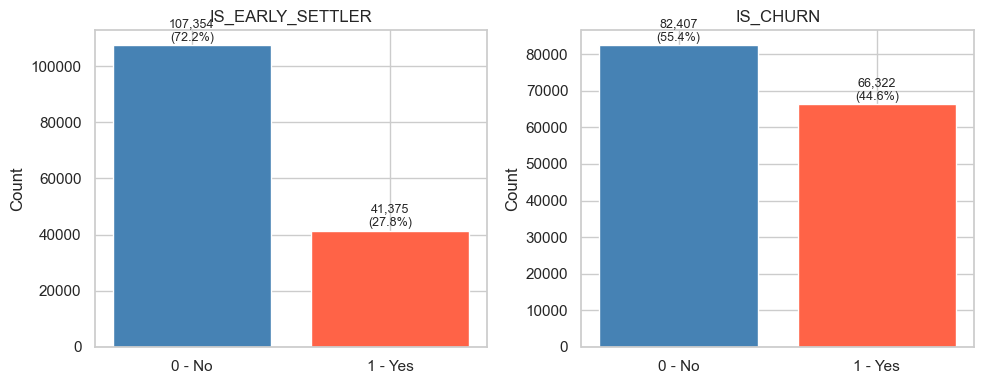

In [38]:
assert "IS_EARLY_SETTLER" in abt.columns and "IS_CHURN" in abt.columns
assert abt["IS_EARLY_SETTLER"].isnull().sum() == 0, "IS_EARLY_SETTLER has nulls!"
assert abt["IS_CHURN"].isnull().sum() == 0, "IS_CHURN has nulls!"

n = len(abt)
for target in ["IS_EARLY_SETTLER", "IS_CHURN"]:
    n1 = abt[target].sum()
    n0 = n - n1
    print(f"{target}:")
    print(f"  0 (negative): {n0:>10,}  ({n0/n*100:.1f}%)")
    print(f"  1 (positive): {n1:>10,}  ({n1/n*100:.1f}%)")
    print(f"  Imbalance ratio (0:1): {n0/n1:.1f}:1\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, target in zip(axes, ["IS_EARLY_SETTLER", "IS_CHURN"]):
    counts = abt[target].value_counts().sort_index()
    ax.bar(["0 - No", "1 - Yes"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
    for i, v in enumerate(counts.values):
        ax.text(i, v + n * 0.003, f"{v:,}\n({v/n*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(target, fontsize=12)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 2.8.9 Data Types & Feature Inventory

In [39]:
dtype_counts = abt.dtypes.value_counts()
print("Column dtype distribution:")
display(dtype_counts.to_frame("count"))

# Any remaining object columns (will probably need encoding later)
obj_cols = abt.select_dtypes(include="object").columns.tolist()
print(f"\nObject (string) columns : {obj_cols}")

# Full column listing
print(f"\nTotal features in ABT : {abt.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(abt.columns, 1):
    print(f"  {i:3d}. {col}")

Column dtype distribution:


,count
float64,66
int64,10
datetime64[ns],9
object,3



Object (string) columns : ['CONTRIB', 'sdem_SITFAM', 'sdem_HABITAT']

Total features in ABT : 88

All columns:
    1. CONTRIB
    2. N_CONTRACTS
    3. FIRST_DCREAT
    4. LAST_DCREAT
    5. LAST_DPOS
    6. LAST_DATFIN
    7. FIRST_D1FIN
    8. MIN_DURDEG
    9. MAX_DURDEG
   10. MEDIAN_DURDEG
   11. MIN_RANGPRO
   12. MAX_RANGPRO
   13. MEDIAN_RANGPRO
   14. MIN_RANGCLI
   15. MAX_RANGCLI
   16. MEDIAN_RANGCLI
   17. TOTAL_MTFIN
   18. TOTAL_MTFINO
   19. TOTAL_MENSALIDADE
   20. TOTAL_CRD
   21. TOTAL_SREC
   22. TOTAL_RN
   23. TOTAL_RD
   24. LAST_RISK
   25. MAX_RISKA
   26. MIN_RESSO
   27. MAX_RESSO
   28. MEDIAN_RESSO
   29. CSP
   30. NBENF
   31. EVER_SOL
   32. N_SOL
   33. EVER_SAN
   34. N_SAN
   35. EVER_RBT
   36. N_RBT
   37. LAST_OBS_DATE_SOL
   38. LAST_OBS_DATE_SAN
   39. LAST_OBS_DATE_RBT
   40. IS_EARLY_SETTLER
   41. IS_CHURN
   42. MT_MENSAL_MIN
   43. MT_MENSAL_MAX
   44. MT_MENSAL_MEDIAN
   45. COUNT_CL_MIN
   46. COUNT_CL_MAX
   47. COUNT_CL_MEDIAN
   48. CO

---
## 2.9 Save ABT

The ABT is saved as a **Parquet file** to `../data/prepared/abt.parquet`.

In [40]:
io.save(abt, ABT_OUT_PATH)

import os
assert os.path.exists(ABT_OUT_PATH), "ABT file not found after save!"

abt_check = pd.read_parquet(ABT_OUT_PATH)
assert abt_check.shape == abt.shape, "Reloaded shape mismatch!"
print(f"\nABT successfully saved and verified: {ABT_OUT_PATH}")
print(f"   Rows: {abt_check.shape[0]:,}  |  Columns: {abt_check.shape[1]}")

[SAVE] ../data/prepared/abt.parquet | shape: (148729, 88)

ABT successfully saved and verified: ../data/prepared/abt.parquet
   Rows: 148,729  |  Columns: 88
